# Delhi Air Quality — Exploratory Data Analysis

Dataset: hourly CPCB sensor readings (2017–2024) from 11 Delhi monitoring
stations (Pusa, IBHAS Dilshad Garden, Sirifort, Jahangirpur, Najafgarh,
Wazirpur, Vivek Vihar, Mundka, Sri Aurobindo Marg, Chandni Chowk, Huda
Sector Fatehabad). 24 pollutant/meteorological variables per station,
70,128 hourly timestamps.

This notebook covers: missing-data profiling, PM2.5 trend analysis
(seasonal + diurnal), station comparison, and pollutant–weather
correlation — the feature groundwork for the forecasting models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_parquet("../data/aq_wide.parquet")
print(df.shape)
df.index = pd.to_datetime(df.index)
df.head()

(70128, 264)


,Pusa__PM2.5,Pusa__PM10,Pusa__NO,Pusa__NO2,Pusa__NOx,Pusa__NH3,Pusa__SO2,Pusa__CO,Pusa__Ozone,Pusa__Benzene,...,Huda_Sector_fatehabad__MP-Xylene,Huda_Sector_fatehabad__AT,Huda_Sector_fatehabad__RH,Huda_Sector_fatehabad__WS,Huda_Sector_fatehabad__WD,Huda_Sector_fatehabad__RF,Huda_Sector_fatehabad__TOT-RF,Huda_Sector_fatehabad__SR,Huda_Sector_fatehabad__BP,Huda_Sector_fatehabad__VWS
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2017-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2017-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2017-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2017-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


## 1. Missing data profile

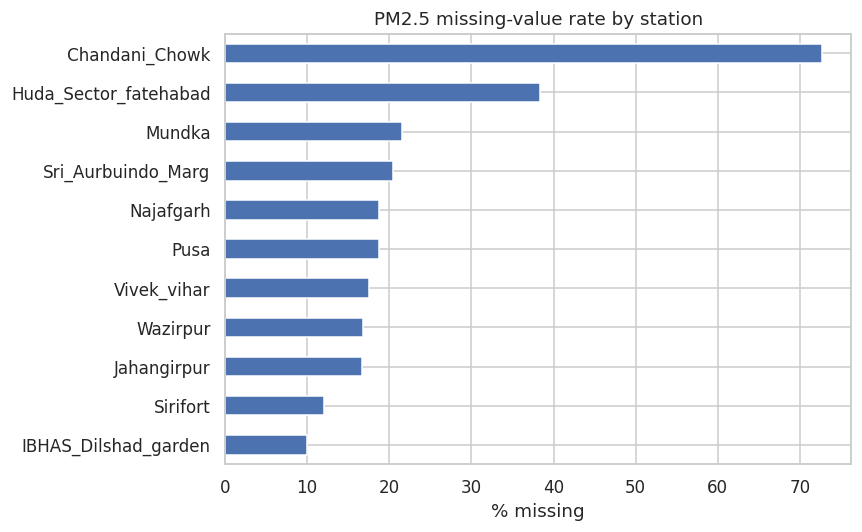

In [2]:
pm25_cols = [c for c in df.columns if c.endswith("__PM2.5")]
missing = df[pm25_cols].isna().mean().sort_values() * 100
missing.index = [c.replace("__PM2.5", "") for c in missing.index]

fig, ax = plt.subplots(figsize=(8, 5))
missing.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% missing")
ax.set_title("PM2.5 missing-value rate by station")
plt.tight_layout()
plt.savefig("../outputs/figures/missing_by_station.png")
plt.show()

## 2. City-wide PM2.5 trend over time

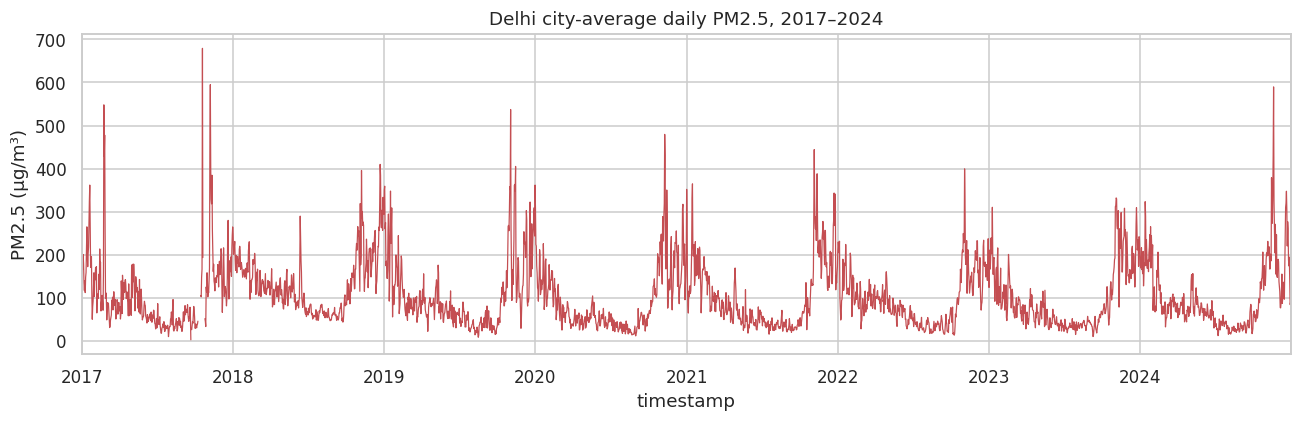

In [3]:
city_pm25 = df[pm25_cols].mean(axis=1)
daily = city_pm25.resample("D").mean()

fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, color="#C44E52", linewidth=0.8)
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Delhi city-average daily PM2.5, 2017–2024")
plt.tight_layout()
plt.savefig("../outputs/figures/pm25_daily_trend.png")
plt.show()

## 3. Seasonality: monthly and diurnal patterns

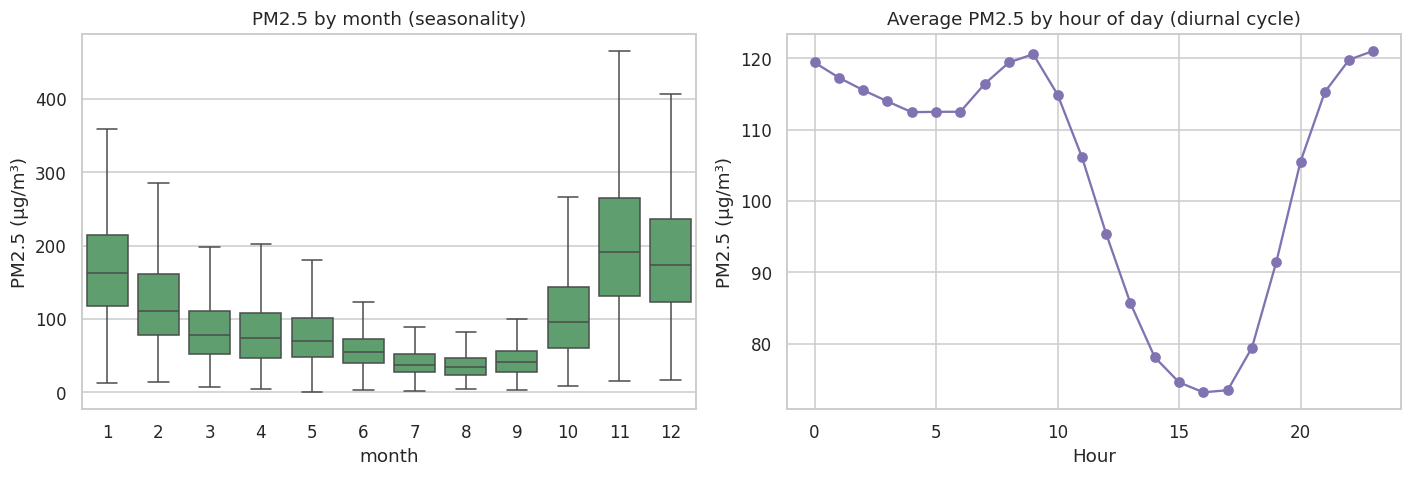

In [4]:
tmp = city_pm25.to_frame("pm25")
tmp["month"] = tmp.index.month
tmp["hour"] = tmp.index.hour

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=tmp, x="month", y="pm25", ax=axes[0], color="#55A868", showfliers=False)
axes[0].set_title("PM2.5 by month (seasonality)")
axes[0].set_ylabel("PM2.5 (µg/m³)")

hourly_avg = tmp.groupby("hour")["pm25"].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, marker="o", color="#8172B2")
axes[1].set_title("Average PM2.5 by hour of day (diurnal cycle)")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig("../outputs/figures/pm25_seasonality_diurnal.png")
plt.show()

## 4. Station comparison — pollution hotspots

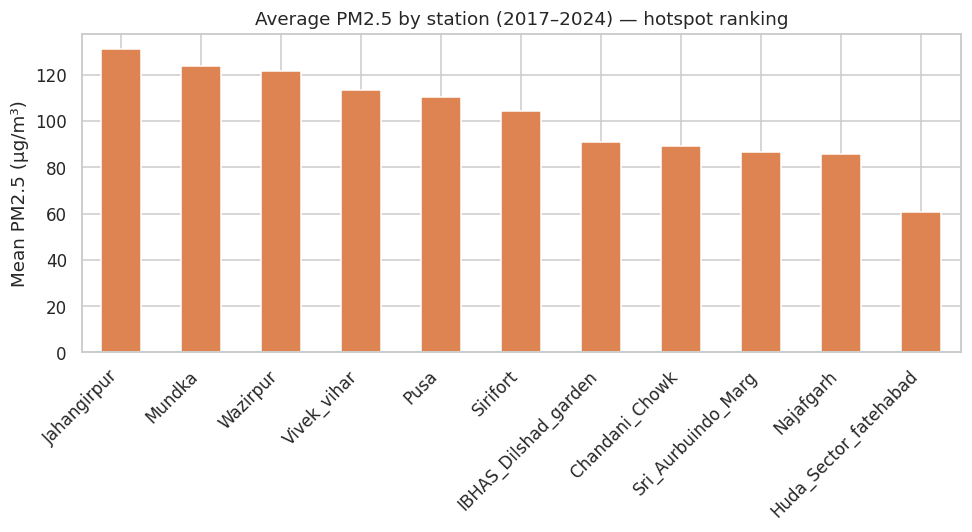

In [5]:
station_avg = df[pm25_cols].mean().sort_values(ascending=False)
station_avg.index = [c.replace("__PM2.5", "") for c in station_avg.index]

fig, ax = plt.subplots(figsize=(9, 5))
station_avg.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_ylabel("Mean PM2.5 (µg/m³)")
ax.set_title("Average PM2.5 by station (2017–2024) — hotspot ranking")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/figures/station_hotspot_ranking.png")
plt.show()

## 5. Pollutant–weather correlation (Pusa station)

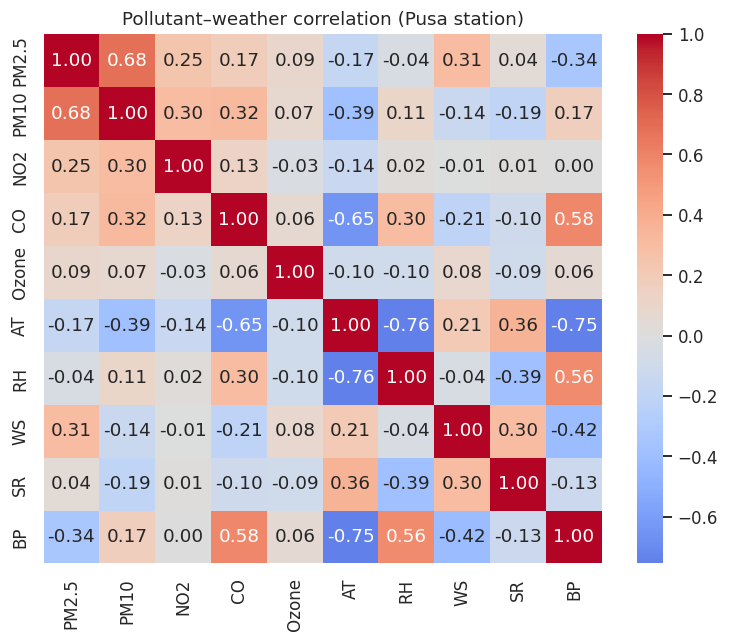

In [6]:
pusa_cols = [c for c in df.columns if c.startswith("Pusa__")]
pusa = df[pusa_cols].copy()
pusa.columns = [c.replace("Pusa__", "") for c in pusa.columns]

keep = ["PM2.5", "PM10", "NO2", "CO", "Ozone", "AT", "RH", "WS", "SR", "BP"]
keep = [k for k in keep if k in pusa.columns]
corr = pusa[keep].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Pollutant–weather correlation (Pusa station)")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png")
plt.show()

## Takeaways

- PM2.5 shows strong **seasonality** (winter peaks due to inversion + stubble
  burning) and a **diurnal** pattern (morning/evening traffic peaks, midday dip
  from thermal mixing).
- **Chandni Chowk** and **Huda Sector Fatehabad** have the highest missing-data
  rates, worth flagging for imputation strategy.
- Station-average ranking identifies persistent **pollution hotspots** —
  directly useful for the hotspot-detection prototype.
- PM2.5 correlates negatively with wind speed and solar radiation, and
  positively with CO/NO2 — confirms combustion + stagnant-air driving factors,
  motivating the lag/rolling features used in the forecasting models next.